In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


===== Logistic Regression =====
Accuracy: 0.7829966157317199
[[6587  198]
 [1918 1048]]
              precision    recall  f1-score   support

           0       0.77      0.97      0.86      6785
           1       0.84      0.35      0.50      2966

    accuracy                           0.78      9751
   macro avg       0.81      0.66      0.68      9751
weighted avg       0.79      0.78      0.75      9751

===== Decision Tree =====
Accuracy: 0.8305814788226848
[[5956  829]
 [ 823 2143]]
              precision    recall  f1-score   support

           0       0.88      0.88      0.88      6785
           1       0.72      0.72      0.72      2966

    accuracy                           0.83      9751
   macro avg       0.80      0.80      0.80      9751
weighted avg       0.83      0.83      0.83      9751

===== Model Comparison =====
Logistic Regression Accuracy: 0.7829966157317199
Decision Tree Accuracy: 0.8305814788226848


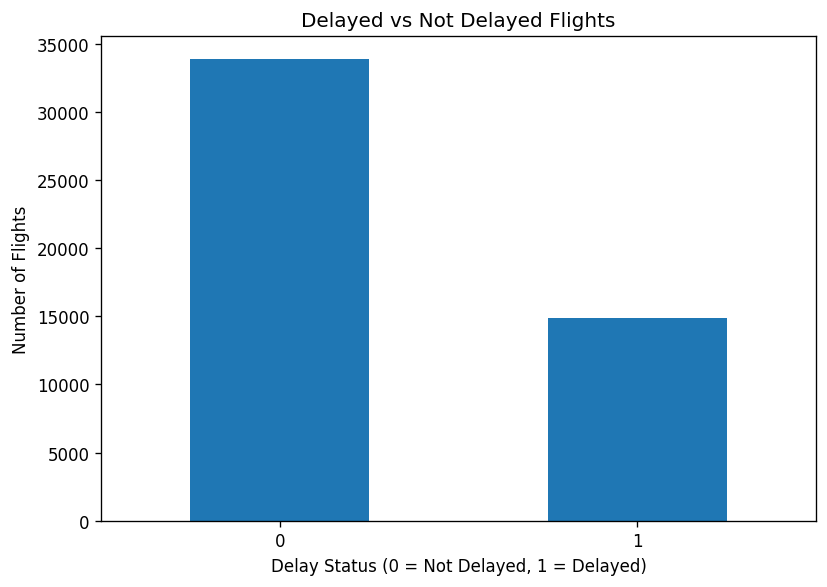

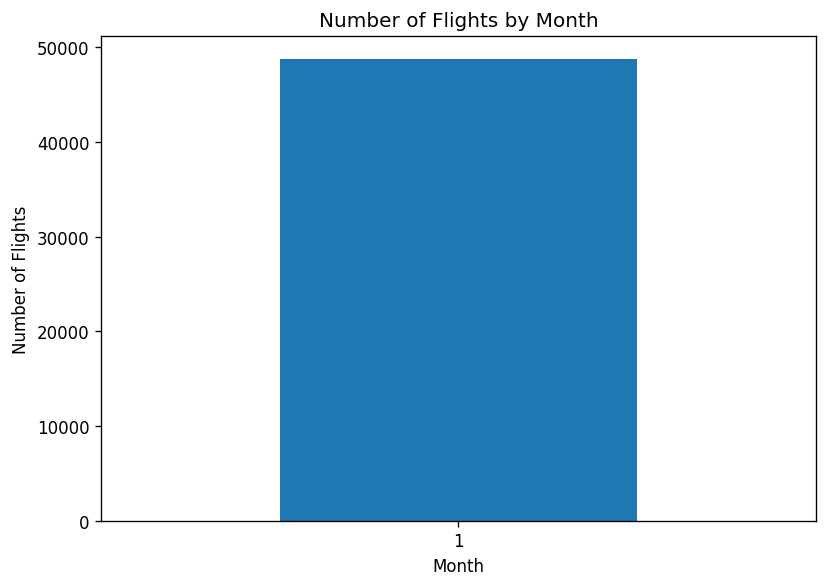

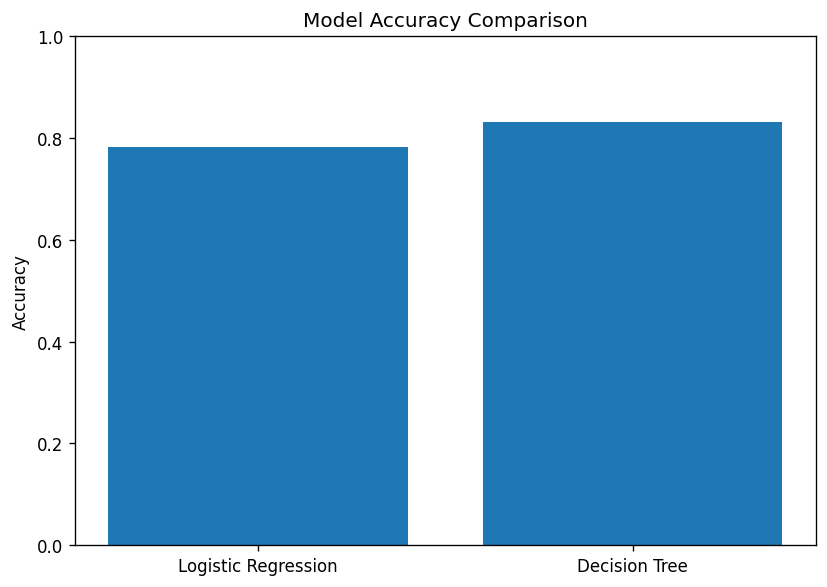

===== Feature Importance =====
DEPARTURE_TIME         0.355190
SCHEDULED_DEPARTURE    0.313283
DISTANCE               0.099360
ORIGIN_AIRPORT         0.067664
DESTINATION_AIRPORT    0.066835
DAY_OF_WEEK            0.060587
AIRLINE                0.037081
MONTH                  0.000000
dtype: float64


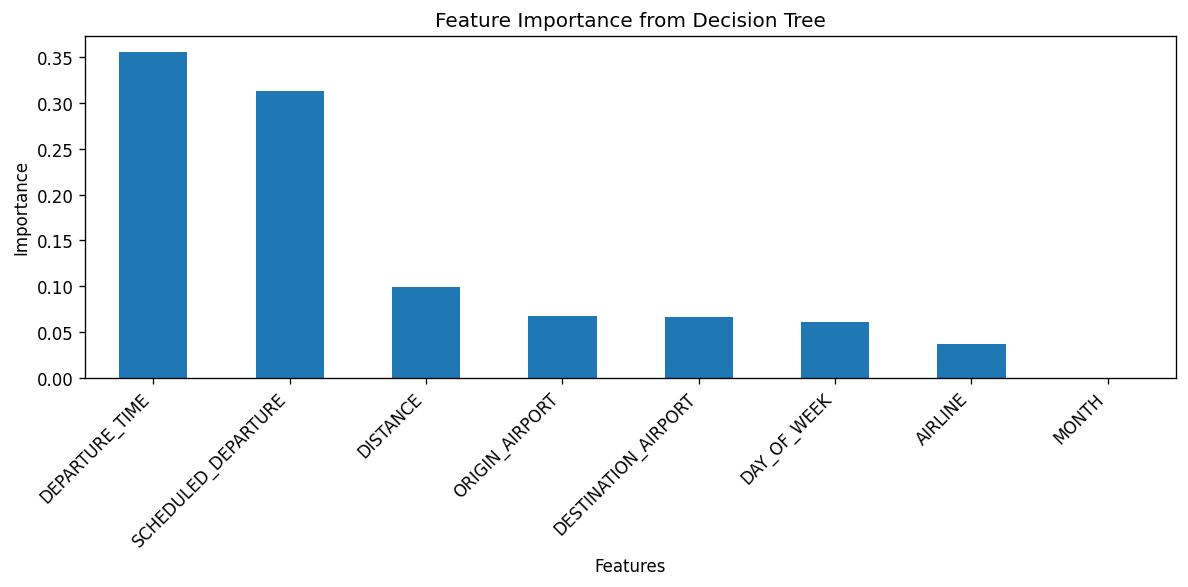

In [21]:
"""
# FLIGHT DELAY PREDICTION - UPDATED VERSION
"""

# For google Colab
%matplotlib inline

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load dataset
#The dataset used in this project is `flights.csv`, downloaded from the Kaggle **Flight Delays** dataset. It contains US flight records with variables such as airline, origin airport, destination airport, scheduled departure time, actual departure time, distance, cancellation status, and arrival delay.

df = pd.read_csv("/content/drive/MyDrive/flights.csv", nrows=50000)

# Keep relevant columns only
df = df[
    [
        'MONTH',
        'DAY_OF_WEEK',
        'AIRLINE',
        'ORIGIN_AIRPORT',
        'DESTINATION_AIRPORT',
        'SCHEDULED_DEPARTURE',
        'DEPARTURE_TIME',
        'DISTANCE',
        'ARRIVAL_DELAY',
        'CANCELLED'
    ]
]

# Clean data
df = df[df['CANCELLED'] == 0]
df = df.dropna()

# Create target variable
df['Delay_Status'] = np.where(df['ARRIVAL_DELAY'] > 15, 1, 0)

# Drop unused columns
df = df.drop(['ARRIVAL_DELAY', 'CANCELLED'], axis=1)

# Encode categorical variables
le_airline = LabelEncoder()
le_origin = LabelEncoder()
le_destination = LabelEncoder()

df['AIRLINE'] = le_airline.fit_transform(df['AIRLINE'])
df['ORIGIN_AIRPORT'] = le_origin.fit_transform(df['ORIGIN_AIRPORT'])
df['DESTINATION_AIRPORT'] = le_destination.fit_transform(df['DESTINATION_AIRPORT'])

# Define features and target
X = df.drop('Delay_Status', axis=1)
y = df['Delay_Status']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale only for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression
lr_model = LogisticRegression(max_iter=500, solver='liblinear')
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("===== Logistic Regression =====")
print("Accuracy:", lr_accuracy)
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("===== Decision Tree =====")
print("Accuracy:", dt_accuracy)
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

print("===== Model Comparison =====")
print("Logistic Regression Accuracy:", lr_accuracy)
print("Decision Tree Accuracy:", dt_accuracy)

# PLOT 1: Delay distribution

plt.close('all')
fig, ax = plt.subplots(figsize=(7, 5))
df['Delay_Status'].value_counts().sort_index().plot(kind='bar', ax=ax)
ax.set_title("Delayed vs Not Delayed Flights")
ax.set_xlabel("Delay Status (0 = Not Delayed, 1 = Delayed)")
ax.set_ylabel("Number of Flights")
ax.tick_params(axis='x', rotation=0)
fig.tight_layout()
plt.show()

fig.savefig("plot1_delay_distribution.png", bbox_inches="tight")

# PLOT 2: Flights by month

plt.close('all')
fig, ax = plt.subplots(figsize=(7, 5))
df['MONTH'].value_counts().sort_index().plot(kind='bar', ax=ax)
ax.set_title("Number of Flights by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Flights")
ax.tick_params(axis='x', rotation=0)
fig.tight_layout()
plt.show()

fig.savefig("plot2_flights_by_month.png", bbox_inches="tight")

# PLOT 3: Model accuracy comparison

plt.close('all')
fig, ax = plt.subplots(figsize=(7, 5))
models = ['Logistic Regression', 'Decision Tree']
accuracies = [lr_accuracy, dt_accuracy]
ax.bar(models, accuracies)
ax.set_title("Model Accuracy Comparison")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
fig.tight_layout()
plt.show()

fig.savefig("plot3_model_accuracy.png", bbox_inches="tight")

# PLOT 4: Feature importance

feature_importance = pd.Series(dt_model.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

print("===== Feature Importance =====")
print(feature_importance)

plt.close('all')
fig, ax = plt.subplots(figsize=(10, 5))
feature_importance.plot(kind='bar', ax=ax)
ax.set_title("Feature Importance from Decision Tree")
ax.set_xlabel("Features")
ax.set_ylabel("Importance")
ax.tick_params(axis='x', rotation=45)
for label in ax.get_xticklabels():
    label.set_horizontalalignment('right')
fig.tight_layout()
plt.show()

fig.savefig("plot4_feature_importance.png", bbox_inches="tight")